[-179.99993 -179.00003 -178.00014 -177.00025 -176.00036 -175.00047
 -174.00058 -173.00069 -172.0008  -171.00091]
[PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im01_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im02_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im03_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im04_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im05_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im06_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im07_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im08_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im09_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im10_mean.tif')]
step info: AcqisitionStep(angle=-179.00003, filepath=PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im02_mean.tif'))


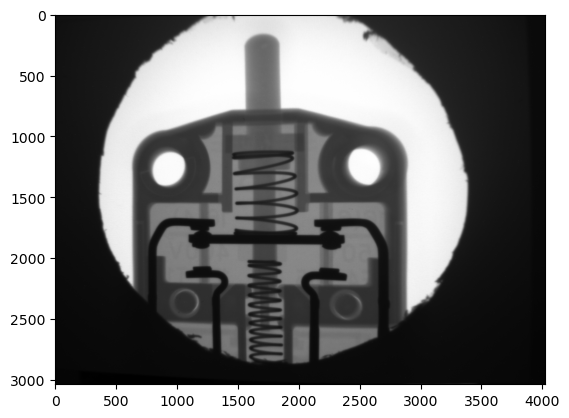

In [2]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import tifffile as tfff
from pathlib import Path, PureWindowsPath

from recon import *
from imaging.img_utils import crop_acquisition

metafile = Path('../data/lab_images/acquisition1/metadata_o.txt')
acq = AcquisitionIndex.from_file(metadata_file=metafile,separator=",")
print(acq._angles[:10])
print(acq._filepaths[:10])

print(f'step info: {acq[1]}')
img = tfff.imread(acq[1].filepath)
plt.imshow(img, cmap='grey')

In [2]:
outdir = acq[0].filepath.parent.parent.parent/'Acc1/cropped'
outdir

PosixPath('../data/lab_images/acquisition1/Acc1/cropped')

In [3]:
col_range=(352,3396)
row_range=(96,2908)
crop_acq = crop_acquisition(acq,
                            outdir=outdir,
                            rows_range=row_range,
                            cols_range=col_range,
                            preffix='crop',
                           )

In [29]:
from datetime import datetime
from pathlib import Path, PureWindowsPath

old_paths = []
for s in acq:
    p = s.filepath.name
    p = "Acc1/raw/"+ p
    old_paths.append(PureWindowsPath(Path(p)))

header = "SDD: 100.0\nSOD: 50.0\nMagnification: 2.000\nPixel Size (um): 3.0\nGain: 27.0\nExposure: 1.0\nImages/step: 5\nStart position: -180.0\n"
with open("metadata_o.txt", 'w') as f:
    f.write(f"Acq1\n")
    f.write(f"Date of creation: {datetime.today().strftime('%Y-%m-%d')}\n")
    f.write(f"============================================================\n")
    f.writelines(header)
    f.write(f"============================================================\n")
    f.write("#,angle,filepath\n")
    for idx, step in enumerate(acq):
        f.writelines(f"{idx},{step.angle},{old_paths[idx]}\n")

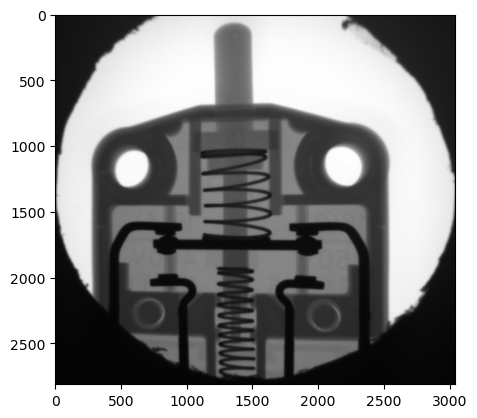

In [15]:
crop_img = tfff.imread(crop_acq[0].filepath)
plt.imshow(crop_img, cmap='grey')

Creating sinogram from row 2200 of 360 images...
  Loaded cropIm01_mean.tif, angle=-179.99993 deg, projection shape: (3044,)
  Loaded cropIm61_mean.tif, angle=-120.00648 deg, projection shape: (3044,)
  Loaded cropIm121_mean.tif, angle=-60.01304 deg, projection shape: (3044,)
Sinogram creation complete. Created 180 projections.


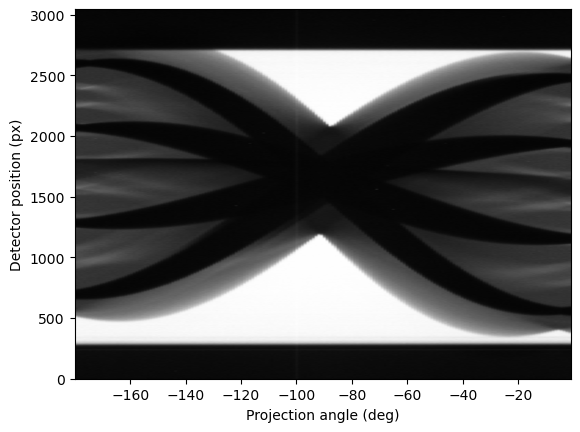

In [16]:
sino = crop_acq.create_sinogram(row=2200, max_projections=180)
sino.plot()

In [17]:
sino._data

array([[209, 184, 162, ..., 187, 204, 180],
       [202, 213, 222, ..., 190, 195, 205],
       [198, 202, 179, ..., 195, 215, 207],
       ...,
       [222, 214, 273, ..., 253, 259, 226],
       [235, 225, 255, ..., 241, 224, 247],
       [217, 240, 252, ..., 257, 260, 270]], dtype=uint16)

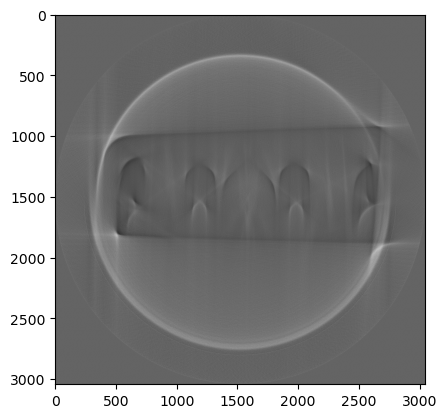

In [15]:
from skimage.transform import iradon
reco = iradon(sino._data, theta=sino._angles, filter_name='ramp')
plt.imshow(reco,cmap='gray')

(281, 304)

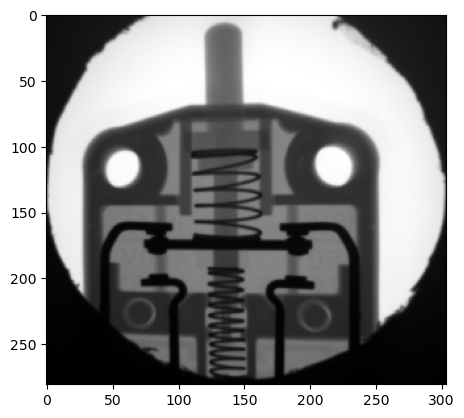

In [19]:
from skimage.transform import rescale
img_rescaled = rescale(crop_img, 0.1, anti_aliasing=True)
plt.imshow(img_rescaled, cmap='gray')
img_rescaled.shape

### If cropped imaes are already created, go here after declaring cropped outdir

step info: AcqisitionStep(angle=-179.00003, filepath=PosixPath('../data/lab_images/acquisition1/Acc1/cropped/cropIm02_mean.tif'))


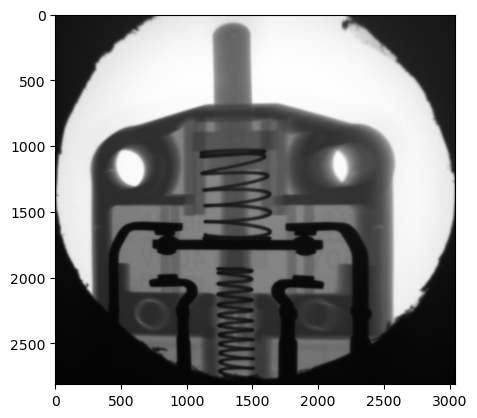

In [3]:
acq_cropped = AcquisitionIndex.from_file(metadata_file=outdir/'metadata.txt',separator=",")
print(f'step info: {acq_cropped[1]}')
img = tfff.imread(acq_cropped[10].filepath)
plt.imshow(img, cmap='grey')

In [4]:
rescaled_outdir = acq_cropped.parent_dir.parent/'rescaled0.1'
rescaled_outdir

PosixPath('../data/lab_images/acquisition1/Acc1/rescaled0.1')

In [5]:
from imaging.img_utils import rescale_acquisition
acq_rescaled = rescale_acquisition(acq_cropped, outdir=rescaled_outdir, preffix='r', scale = 0.1, log_fn=print)

Images in the acquisition were rescaled to size (281, 304)



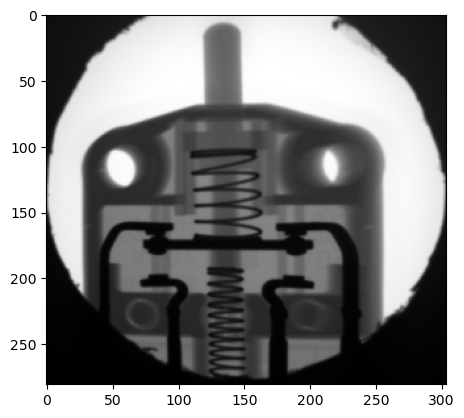

In [6]:
imr = tfff.imread(acq_rescaled[10].filepath)
plt.imshow(imr, cmap='gray')

Creating sinogram from row 240 of 360 images...
  Loaded rcropIm01_mean.tif, angle=-179.99993 deg, projection shape: (304,)
  Loaded rcropIm61_mean.tif, angle=-120.00648 deg, projection shape: (304,)
  Loaded rcropIm121_mean.tif, angle=-60.01304 deg, projection shape: (304,)
Sinogram creation complete. Created 180 projections.


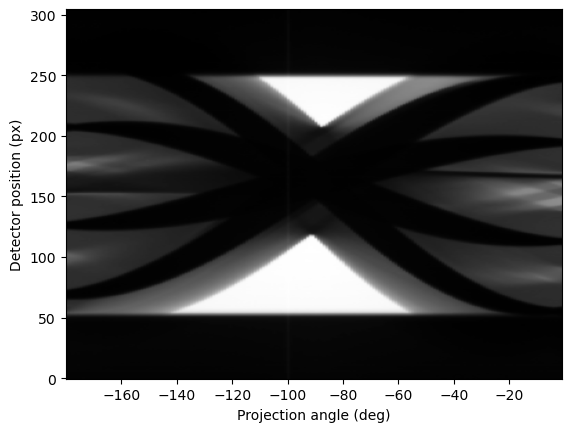

In [25]:
sino_rescaled = acq_rescaled.create_sinogram(row=240, max_projections=180)
sino_rescaled._data
sino_rescaled.plot()

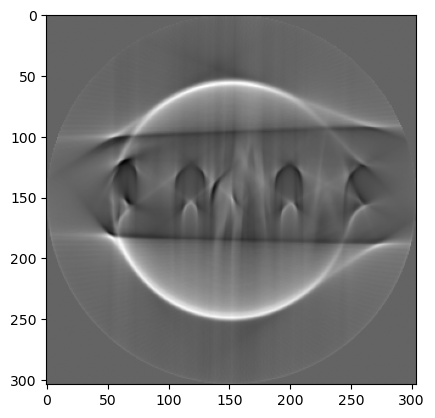

In [26]:
from skimage.transform import iradon
reco_rescaled=iradon(sino_rescaled._data, sino_rescaled._angles, filter_name='ramp')
plt.imshow(reco_rescaled, cmap='gray')